### Iter - 3 GMM-spherical MinMaxScaler

In [0]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, silhouette_samples


df_user_behavior = spark.table('workspace.spotify.spotify_user_behavior').toPandas()

CLUSTER_FEATURES_V3 = [
    'daily_listening_minutes',  # usage intensity
    'sessions_per_day',         # frequency
    'days_active_last_30',      # consistency
    'avg_session_minutes',      # depth
    'skip_rate',                # content friction
    'liked_songs_pct',          # positive engagement
    'ads_skipped_pct'           # monetization friction
]

In [0]:
base = df_user_behavior[['user_id'] + CLUSTER_FEATURES_V3].copy()
before_rows = len(base)
base = base.dropna(subset = CLUSTER_FEATURES_V3)
after_rows = len(base)

if before_rows != after_rows:
    print(f' Dropped {before_rows - after_rows} rows due to nulls')

In [0]:
n = 4 # 3-4 clusters are consider for business personas

In [0]:
X3= base[CLUSTER_FEATURES_V3].copy()

scaler = MinMaxScaler()

X3_scaled = scaler.fit_transform(X3)
X3 = pd.DataFrame(
    X3_scaled,
    columns = CLUSTER_FEATURES_V3,
    index = base.index
)

gmm3 = GaussianMixture(
    n_components = n,
    covariance_type = 'spherical',
    n_init=20,
    max_iter=100,
    random_state = 42
)


In [0]:
labels3 = gmm3.fit_predict(X3)
inertia3 = gmm3.bic(X3)

sil_avg_3= silhouette_score(X3, labels3)
base_iter3 = base.copy()
base_iter3['cluster']= labels3
print(f'Inertia: {round(inertia3,2)}')
print(f' Silhoutte: {round(sil_avg_3,2)}')
sizes3 = base_iter3['cluster'].value_counts().sort_index()
sizes3


Inertia: -861700.01
 Silhoutte: 0.18


cluster
0    30691
1    18189
2    31455
3    27665
Name: count, dtype: int64

In [0]:
means3= (
    base_iter3.groupby('cluster')[CLUSTER_FEATURES_V3].mean().round(3))

In [0]:
profile3 = means3.copy()
profile3.insert(0, 'cluster_size', sizes3)
display(profile3)

cluster_size,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
30691,47.796824131085245,1.361,25.550397120852193,36.05108959078743,0.256,0.3518436480706324,0.4140897898203969
18189,29.52239953926489,1.21,22.273704944118805,24.516699226477748,0.594,0.2546602795047134,0.48682408330267884
31455,50.72326889813787,1.385,21.481276572450227,38.54328444760595,0.281,0.2751263073490462,0.76826875556113
27665,34.11313280406714,1.225,15.237703279045364,28.527976108144355,0.276,0.24668714231580136,0.46995855483167653


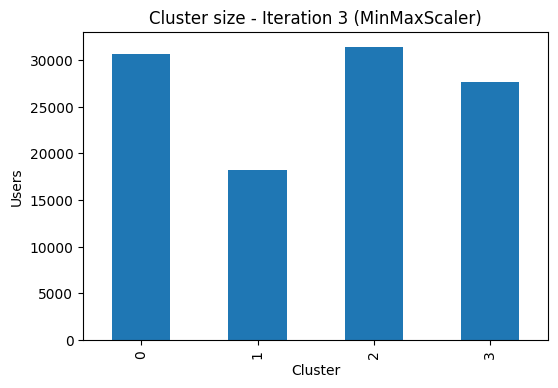

In [0]:
import matplotlib.pyplot as plt
plt.figure(figsize = (6,4)) 

base_iter3['cluster'].value_counts().sort_index().plot(kind= 'bar')
plt.title('Cluster size - Iteration 3 (MinMaxScaler)')
plt.xlabel('Cluster')
plt.ylabel('Users')
plt.show()

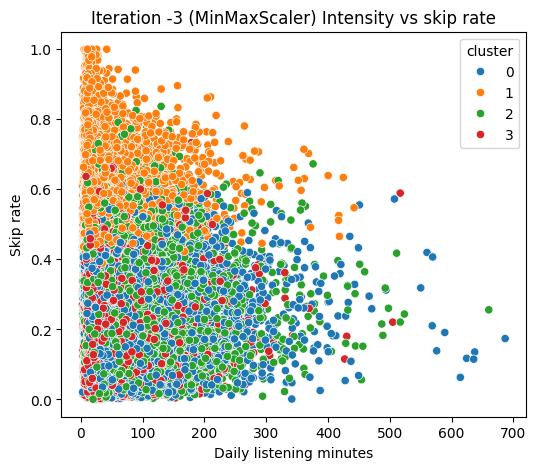

In [0]:
# scatter plot (No PCA)

# intensity vs skip
import seaborn as sns

plt.figure(figsize= (6,5))
sns.scatterplot(
    data = base_iter3,
    x = 'daily_listening_minutes',
    y = 'skip_rate',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('Iteration -3 (MinMaxScaler) Intensity vs skip rate')
plt.xlabel('Daily listening minutes')
plt.ylabel('Skip rate')
plt.show()

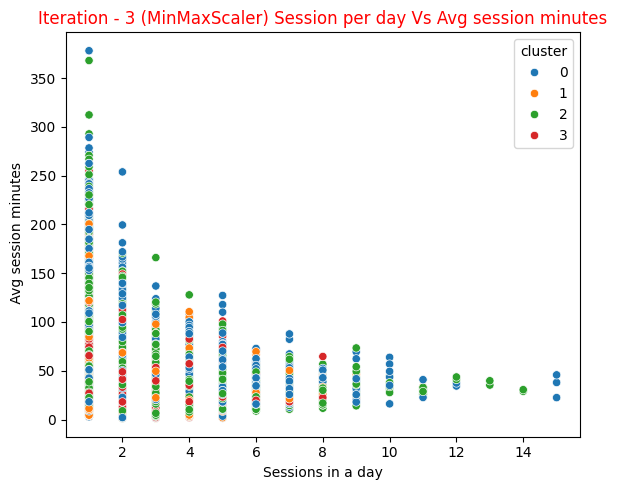

In [0]:
# frequency vs Session depth

plt.figure(figsize= (6,5))

sns.scatterplot(
    data = base_iter3,
    x = 'sessions_per_day',
    y= 'avg_session_minutes',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('Iteration - 3 (MinMaxScaler) Session per day Vs Avg session minutes', color = 'red')
plt.xlabel('Sessions in a day')
plt.ylabel(' Avg session minutes')
plt.tight_layout()
plt.show()

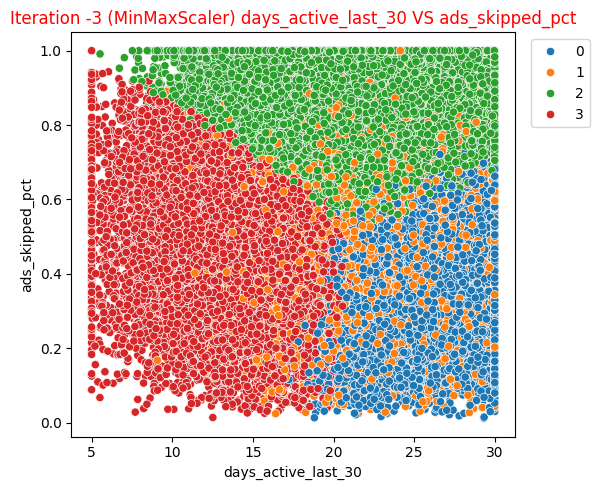

In [0]:
# consistance vs Ad friction

plt.figure(figsize= (6,5))

sns.scatterplot(
    data = base_iter3,
    x = 'days_active_last_30',
    y= 'ads_skipped_pct',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('Iteration -3 (MinMaxScaler) days_active_last_30 VS ads_skipped_pct', color = 'red')
plt.legend(bbox_to_anchor = (1.02, 1))
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

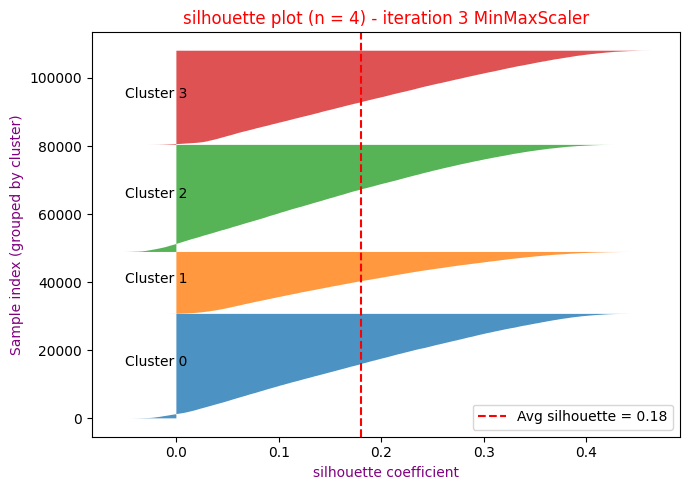

In [0]:
# silhouette Plot

sil_values_3 = silhouette_samples(X3, labels3)
sil_avg_3 = silhouette_score(X3, labels3)
plt.figure(figsize= (7,5))

y_lower = 0

vals0 = sil_values_3[labels3 == 0]
vals0.sort()
size0 = vals0.shape[0]

y_upper = y_lower + size0

plt.fill_betweenx(
    np.arange(y_lower, y_upper),    # vertical span
    0,                              # left boundary (silhoutte = 0)
    vals0,                          # right boundary (actual silhoutte values)
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5 * size0,  # slightly left of zero
    'Cluster 0'             # vertically centered
)

y_lower = y_upper

# Cluster 1
vals1 = sil_values_3[labels3==1]
vals1.sort()
size1 = vals1.shape[0]

y_upper = y_lower + size1

plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals1,
    alpha = 0.8
    )
plt.text(-0.05,
         y_lower + 0.5 * size1, 'Cluster 1')

y_lower = y_upper

# cluster 2
vals2 = sil_values_3[labels3 == 2]
vals2.sort()

size2 = vals2.shape[0]
y_upper = y_lower + size2
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals2, alpha = 0.8)
plt.text(-0.05, y_lower + 0.5 * size2, 'Cluster 2')

y_lower = y_upper

# cluster 3
vals3 = sil_values_3[labels3 == 3]
vals3.sort()
size3 = vals3.shape[0]
y_upper = y_lower + size3
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals3, alpha = 0.8)
plt.text(-0.05, y_lower + 0.5 * size3, 'Cluster 3')

y_lower = y_upper

plt.axvline(
    x= sil_avg_3,
    color = 'red',
    linestyle = '--',
    label =f"Avg silhouette = {sil_avg_3:.2f}"
)

plt.title('silhouette plot (n = 4) - iteration 3 MinMaxScaler', color = 'red')
plt.xlabel('silhouette coefficient', color = 'purple')
plt.ylabel('Sample index (grouped by cluster)', color = 'purple')
plt.legend()
plt.tight_layout()
plt.show